In [8]:
# Parameters
name      = ""
fits_path = ""

In [10]:
import time
start_time=time.time()

In [25]:
import numpy as np
import seaborn as sns
import pandas as pd
import sys
from pathlib import Path
import astropy.units as u
from matplotlib import pyplot as plt
import corner
import json
from astropy.io import fits
from lmfit.model import save_modelresult


# Add path to py_modules 
sys.path.append(str(Path().resolve() / 'py_modules')) # 1 level up = project root

#import strucfunc                   
import strucfunc
import fit_structure_function
import ci_results_compiler
import bfunc
import bplot

# Velocity Field

In [17]:
# Loading obs
hdul = fits.open(fits_path)
hdr = hdul[0].header
print(hdul.info())
print(hdr)
sb = hdul['MOM0'].data.astype(float)
vv= hdul['MOM1'].data.astype(float)

Filename: fits_ready/MUSE-Dor-H.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU      14   ()      
  1  MOM0          1 ImageHDU         8   (560, 590)   float64   
  2  MOM1          1 ImageHDU         8   (560, 590)   float64   
  3  MOM2          1 ImageHDU         8   (560, 590)   float64   
None
SIMPLE  =                    T / conforms to FITS standard                      BITPIX  =                    8 / array data type                                NAXIS   =                    0 / number of array dimensions                     EXTEND  =                    T                                                  INSTR   = 'MUSE    '                                                            AUTHOR  = 'J. Garcia-Vazquez'  / File creator                                   SIG     =   264.94496067688533 / Standard deviation vel artificial map          SIG2    =    70195.83218807631 / Vel Variance artificial map                    S0     

In [18]:
with fits.open(fits_path) as hdul:
    hdr = hdul[0].header

hdr

SIMPLE  =                    T / conforms to FITS standard                      
BITPIX  =                    8 / array data type                                
NAXIS   =                    0 / number of array dimensions                     
EXTEND  =                    T                                                  
INSTR   = 'MUSE    '                                                            
AUTHOR  = 'J. Garcia-Vazquez'  / File creator                                   
SIG     =   264.94496067688533 / Standard deviation vel artificial map          
SIG2    =    70195.83218807631 / Vel Variance artificial map                    
S0      =  0.21816615649929116 / Atmospheric seeing                             
BOX_SIZE=   27.867299564396152 / Observational box_size                         
PC      =  0.24240684055476797 / parsec convertion                              
PIX     =                  0.2 / Instrument pixel scale                         
LINE    = 'H_I-6563'        

In [15]:
#m3D      = hdul[0].header['M3D']
#ra       = hdul[0].header['RA']
sig      = hdul[0].header['SIG']
sig2     = hdul[0].header['SIG2']
s0       = hdul[0].header['S0']
#noise    = hdul[0].header['NOISE']
box_size = hdul[0].header['BOX_SIZE']
pc       = hdul[0].header['PC']
pix      = hdul[0].header['PIX']
line     = hdul[0].header['LINE']
binsize  = hdul[0].header['BINSIZE']

<>:11: SyntaxWarning: invalid escape sequence '\s'
<>:11: SyntaxWarning: invalid escape sequence '\s'
C:\Users\ZAINTEL2\AppData\Local\Temp\ipykernel_21040\669126516.py:11: SyntaxWarning: invalid escape sequence '\s'
  cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)


Text(0.5, 1.0, 'Moment 0')

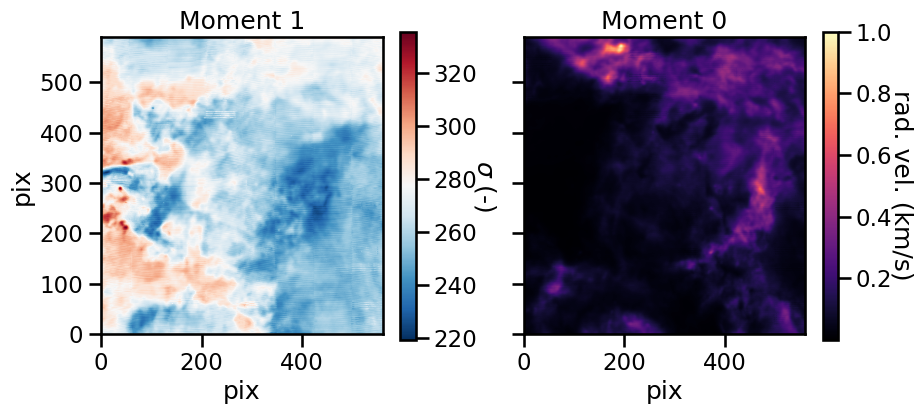

In [21]:
fig, (ax, axx) = plt.subplots(
    1,
    2,
    sharey=True,
    figsize=(10, 4),
)
imshow_kwds = dict(origin="lower", cmap="RdBu_r")
imshow_kwds2 = dict(origin="lower", cmap="magma")
im = ax.imshow(vv, **imshow_kwds)
cbar = fig.colorbar(im, ax=[ax])
cbar.set_label("$\sigma$ (-)", rotation=270, labelpad=15)
im = axx.imshow(sb, **imshow_kwds2)
cbar = fig.colorbar(im, ax=[axx])
cbar.set_label("rad. vel. (km/s)", rotation=270, labelpad=15)

ax.set_xlabel("pix")
ax.set_ylabel("pix")
axx.set_xlabel("pix")
ax.set_title("Moment 1")
axx.set_title("Moment 0")

# Structure function

In [33]:
rslt = strucfunc.strucfunc_numba_parallel(vv, wmap=sb, dlogr=0.05)

C:\Users\ZAINTEL2\Dropbox\GitHub\30dor_MUSE\py_modules\strucfunc.py:83: RuntimeWarning: invalid value encountered in divide
  'Unweighted B(r)': sf/nsf,
C:\Users\ZAINTEL2\Dropbox\GitHub\30dor_MUSE\py_modules\strucfunc.py:84: RuntimeWarning: invalid value encountered in divide
  'Weighted B(r)': wsf/weight}


In [34]:
rslt_ = pd.DataFrame(rslt)

In [40]:
rslt["Unweighted mean velocity"] = np.mean(vv)
rslt["Unweighted sigma^2"] = np.var(vv)
v0w = rslt["Weighted mean velocity"] = np.average(vv, weights=sb)
rslt["Weighted sigma^2"] = np.average((vv - v0w)**2, weights=sb)

In [41]:
b2    = rslt['Unweighted B(r)']
b2w   = rslt['Weighted B(r)']
e_b2  = b2  *.1
e_b2w = b2w  *.1

s     = 10**rslt['log10 r'] * pix * pc
e_s   = s  *.1
sig2  = rslt['Unweighted sigma^2']
sig2w = rslt['Weighted sigma^2']

sig   = sig2**0.5

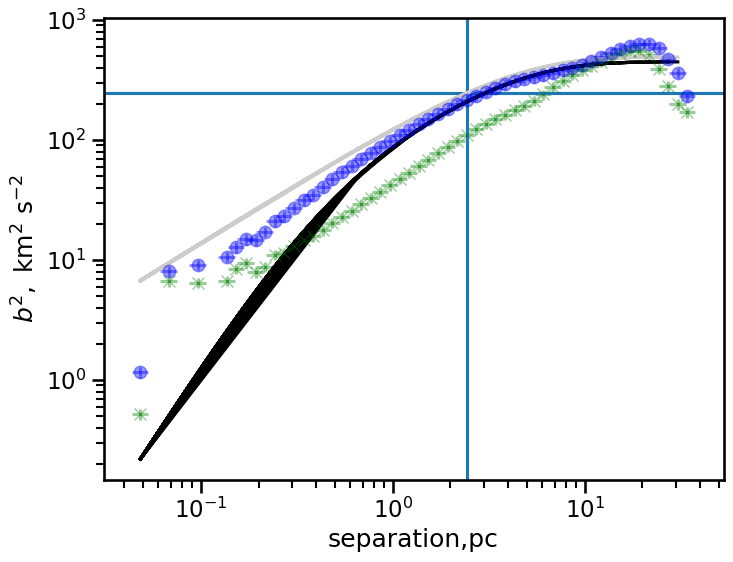

In [43]:
r0    = np.interp(sig2, b2[1:35], s[1:35])
ra = r0
m     = 1
noise = 0

rgrid = np.linspace(s[0], s[:-1])

fig, ax = plt.subplots(figsize=(8, 6))

ax.errorbar(s, b2, yerr=e_b2, xerr=e_s, fmt='o', alpha=0.4,color="blue")
ax.errorbar(s, b2w, yerr=e_b2w, xerr=e_s, fmt='x', alpha=0.4,color="green")

ax.axhline(sig2, ls='-')
ax.axvline(r0, ls='-')

ax.plot(rgrid, bfunc.bfunc00s(rgrid, r0, sig2, m), color="0.8")
ax.plot(rgrid, bfunc.bfunc03s(rgrid, r0, sig2, m, s0, noise), color="black")
#ax.plot(rgrid, bfunc.bfunc04s(rgrid, r0, sig2, m, s0, noise, box_size), color="black")


ax.set(xscale='log', yscale='log', 
       xlabel='separation,pc',
       ylabel=r'$b^2,\ \mathrm{km^2\ s^{-2}}$'
      )
None

plt.show()



# Export

In [49]:
from astropy.table import Table


df =  rslt_.copy()

# Flatten MultiIndex columns like ('s','count') -> "s_count"
if isinstance(df.columns, pd.MultiIndex):
    df.columns = ["_".join(map(str, col)).strip() for col in df.columns.to_flat_index()]
else:
    df.columns = [str(c) for c in df.columns]

# (Optional) drop index to avoid it becoming an extra column
df = df.reset_index(drop=True)

t = Table.from_pandas(df)
new_hdu = fits.BinTableHDU(t, name="TABLE")

In [50]:
with fits.open(fits_path, mode="readonly") as hdul:
    hdus = [h.copy() for h in hdul]   # copy existing HDUs

hdus.append(new_hdu)
fits.HDUList(hdus).writeto(fits_path, overwrite=True)

In [51]:
# Test import

from astropy.table import Table
t = Table.read(fits_path, hdu="TABLE")
df_loaded = t.to_pandas()
df_loaded


In [52]:
print("--- %s seconds ---" % (time.time()-start_time))

--- 3066.401252746582 seconds ---
